In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim

import torchvision #special library for computer vision(that contain datasets,pretrained CNNs and utilities for image transformation
from torchvision.datasets import MNIST

In [2]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

trainset=MNIST(root="./data",train=True,download=True,transform=transform)
testset=MNIST(root="./data",train=False,download=True,transform=transform)

100%|██████████████████████████████████████| 9.91M/9.91M [00:02<00:00, 4.06MB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 125kB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.03MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.79MB/s]


In [3]:
#converting to data loader
train_loader=DataLoader(trainset,batch_size=64,shuffle=True)
test_loader=DataLoader(testset,batch_size=64) 

In [4]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


## Build CNN

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv_layers=nn.Sequential(
            #1st layer
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
         #2nd layer
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
            
        )
        self.fc_layers=nn.Sequential(
            nn.Linear(7*7*64,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    def forward(self,x):
        x=self.conv_layers(x)
        x=x.view(x.size(0),-1)
        x=self.fc_layers(x)
        return x

In [6]:
model=CNN()

In [7]:
#loss and optimizers
criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(model.parameters())

## Training the CNN

In [8]:
epochs=10

for epoch in range(epochs):
    model.train()
    train_loss=0.0
    for images,labels in train_loader:
        optimizer.zero_grad()
        
        output=model(images)
        
        loss=criterion(output,labels)
        loss.backward() #back propogation
        
        optimizer.step() #update our parameters
        
        train_loss+=loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}")
    

Epoch [1/10], Loss: 0.1588
Epoch [2/10], Loss: 0.0465
Epoch [3/10], Loss: 0.0305
Epoch [4/10], Loss: 0.0219
Epoch [5/10], Loss: 0.0177
Epoch [6/10], Loss: 0.0142
Epoch [7/10], Loss: 0.0106
Epoch [8/10], Loss: 0.0091
Epoch [9/10], Loss: 0.0085
Epoch [10/10], Loss: 0.0069


## evaluation

In [9]:
model.eval()
correct_val=0
total_val=0
y_true=[]
y_pred=[]
with torch.no_grad():
    for images,labels in test_loader:
        outputs=model(images)
        _,predicted=torch.max(outputs,1)
        
        correct_val+=(predicted==labels).sum().item()
        total_val+=labels.size(0)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        
print(f"Test Accuracy: {correct_val/total_val*100:.2f}%")           

Test Accuracy: 99.14%


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision:", precision*100)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Recall:", recall*100)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1*100)

Precision: 99.14309788665989
Recall: 99.14
F1 Score: 99.14001873042642


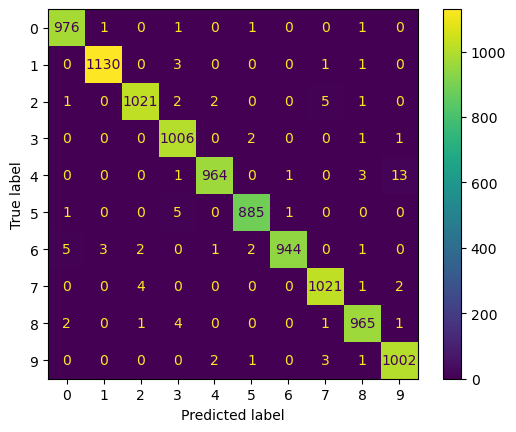

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

#Rows = Actual digits
#Columns = Predicted digits

# RNN

## build RNN

In [12]:
class RNN(nn.Module):
    def __init__(self,input_size,hidden_size=128,num_layers=1):
        super().__init__()

        self.hidden_size=hidden_size
        self.num_layers=num_layers

        #RNN Layers
        self.rnn=nn.RNN(input_size,hidden_size,num_layers,batch_first=True)

         #fully connected layer
        self.fc=nn.Linear(hidden_size,10)

    def forward(self,x):
        h0=torch.zeros(self.num_layers,x.size(0),self.hidden_size) 
        out,hidden=self.rnn(x,h0)
        out=self.fc(out[:, -1, :]) #from here we will get final output 
        return out

In [13]:

model=RNN(input_size=28)

#loss and optimizers
criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(model.parameters())

## training the model

In [14]:
epochs=10

for epoch in range(epochs):
    model.train()
    train_loss=0.0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        xb = xb.squeeze(1)
        output=model(xb)
        loss=criterion(output,yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}")
        

Epoch [1/10], Loss: 0.7568
Epoch [2/10], Loss: 0.3452
Epoch [3/10], Loss: 0.2385
Epoch [4/10], Loss: 0.1976
Epoch [5/10], Loss: 0.1771
Epoch [6/10], Loss: 0.1584
Epoch [7/10], Loss: 0.1471
Epoch [8/10], Loss: 0.1407
Epoch [9/10], Loss: 0.1338
Epoch [10/10], Loss: 0.1260


## evaluation

In [15]:
model.eval()
correct_val=0
total_val=0
y_true=[]
y_pred=[]
with torch.no_grad():
    for xb,yb in test_loader:
        xb=xb.squeeze(1)
        outputs=model(xb)
        _,predicted=torch.max(outputs,1)
        
        correct_val+=(predicted==yb).sum().item()
        total_val+=yb.size(0)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        
        
print(f"Test Accuracy: {correct_val/total_val*100:.2f}%")           



Test Accuracy: 95.85%


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision:", precision*100)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Recall:", recall*100)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1*100)


Precision: 95.88485850661445
Recall: 95.85000000000001
F1 Score: 95.85534847457934


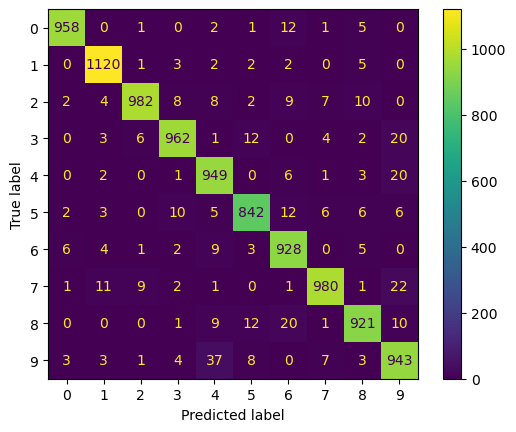

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()